# Spotter Freight Rate Prediction — Exploratory Data Analysis

## Objective

Explore the provided freight load dataset to understand:

- Dataset structure
- Feature types
- Missing values
- Duplicate records
- Target variable distribution
- Numerical relationships
- Categorical variables
- Temporal patterns
- Potential data leakage
- Considerations for model validation

In [433]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [434]:
df = pd.read_csv("../data/train-test.csv")
df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [435]:
print("Shape:", df.shape)
print("\nData types and non-null counts:")
df.info()

Shape: (48000, 14)

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [436]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64


In [437]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64


In [438]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate load IDs:", df["load_id"].duplicated().sum())

Duplicate rows: 0
Duplicate load IDs: 0


In [439]:
print("First date is ", df["date"].min()) 
print("Last date is ", df["date"].max()) 

First date is  2025-01-01
Last date is  2025-10-31


In [440]:
print("Number of unique dates:", df["date"].nunique())


Number of unique dates: 304


In [441]:
print(df["date"].value_counts().sort_index().head(10))


date
2025-01-01    145
2025-01-02    168
2025-01-03    156
2025-01-04    156
2025-01-05    154
2025-01-06    168
2025-01-07    161
2025-01-08    189
2025-01-09    148
2025-01-10    173
Name: count, dtype: int64


In [442]:
df.describe()   

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [443]:
df[[
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]].describe()

,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,3439.800000,47500.000000,1.467780,3.610350,25533.000000


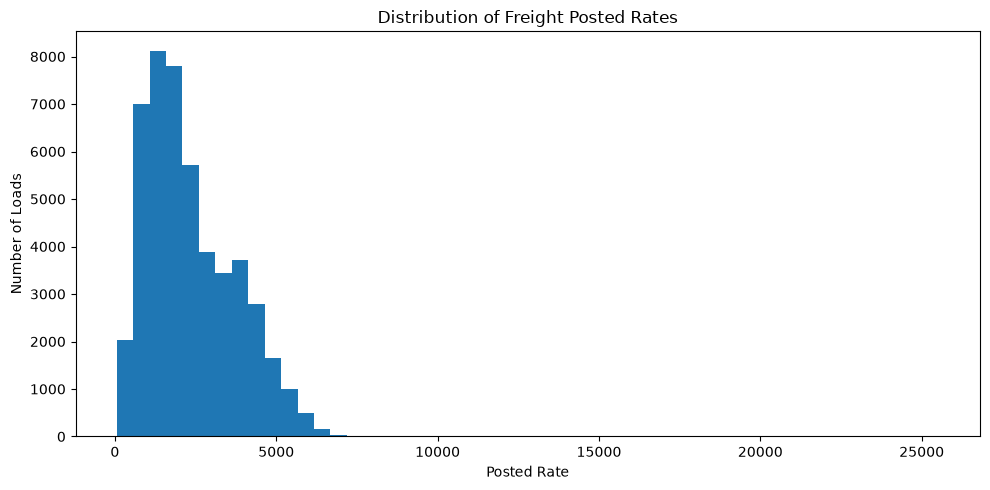

In [444]:
plt.figure(figsize=(10, 5))

plt.hist(df["posted_rate"], bins=50)

plt.xlabel("Posted Rate")
plt.ylabel("Number of Loads")
plt.title("Distribution of Freight Posted Rates")

plt.tight_layout()
plt.show()

In [445]:
df[df["weight"] < 0][["load_id", "weight", "distance", "equipment", "posted_rate"]].head(20)

,load_id,weight,distance,equipment,posted_rate
68,TR-000069,-36559.0,1334.2,Reefer,2831.27
204,TR-000205,-26670.0,496.2,Dry Van,1046.92
206,TR-000207,-20003.0,411.3,Reefer,959.15
225,TR-000226,-23981.0,1317.4,Reefer,2836.00
376,TR-000377,-41397.0,1331.1,Dry Van,2522.54
446,TR-000447,-37215.0,2438.3,Reefer,4841.57
495,TR-000496,-31214.0,715.9,Dry Van,1473.78
641,TR-000642,-41023.0,582.4,Dry Van,1264.33
806,TR-000807,-28320.0,676.1,Dry Van,1307.76
1093,TR-001094,-25153.0,1058.5,Dry Van,1907.83


In [446]:
print("Negative weights:", (df["weight"] < 0).sum())

Negative weights: 292


In [447]:
df.loc[df["weight"] < 0, "weight"].describe()

count      292.000000
mean    -31724.195205
std       8262.536326
min     -47500.000000
25%     -37284.250000
50%     -31821.500000
75%     -25928.500000
max      -5000.000000
Name: weight, dtype: float64

In [448]:
df[df["weight"] < 0]["weight"].value_counts().sort_index()

weight
-47500.0    13
-46334.0     1
-46187.0     1
-45975.0     1
-45588.0     1
            ..
-13852.0     1
-13119.0     1
-12836.0     1
-11574.0     1
-5000.0      1
Name: count, Length: 275, dtype: int64

In [449]:
df.groupby(df["weight"] < 0)["posted_rate"].describe()

,count,mean,std,min,25%,50%,75%,max
weight,,,,,,,,
False,47708.0,2373.883943,1485.511426,57.22,1251.555,2031.16,3331.2250,25533.00
True,292.0,2389.786233,1641.761285,247.37,1257.410,1994.96,3185.2575,14561.21


In [450]:
df.groupby(df["weight"]< 0)["distance"].mean()

weight
False    1135.948074
True     1120.920205
Name: distance, dtype: float64

In [451]:
df.groupby(df["weight"] < 0)["quote_signal"].mean()

weight
False    2.062593
True     2.041966
Name: quote_signal, dtype: float64

In [452]:
df.groupby(df["weight"] < 0)["quote_signal"].mean()

weight
False    2.062593
True     2.041966
Name: quote_signal, dtype: float64

In [453]:
df[df["weight"] < 0][
    [
        "load_id",
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "market_index",
        "quote_signal",
        "posted_rate"
    ]
].head(20)

,load_id,pickup,delivery,distance,equipment,weight,market_index,quote_signal,posted_rate
68,TR-000069,Amarillo,Dayton,1334.2,Reefer,-36559.0,0.96102,2.11777,2831.27
204,TR-000205,Fresno,Tucson,496.2,Dry Van,-26670.0,0.96903,2.13155,1046.92
206,TR-000207,Columbia,Raleigh,411.3,Reefer,-20003.0,0.94800,2.31682,959.15
225,TR-000226,Greensboro,Lubbock,1317.4,Reefer,-23981.0,1.00820,2.13918,2836.00
376,TR-000377,Madison,Providence,1331.1,Dry Van,-41397.0,0.94787,1.91867,2522.54
446,TR-000447,Albuquerque,Albany,2438.3,Reefer,-37215.0,0.96575,1.96959,4841.57
495,TR-000496,Montgomery,Dayton,715.9,Dry Van,-31214.0,0.85153,2.03947,1473.78
641,TR-000642,Tulsa,Indianapolis,582.4,Dry Van,-41023.0,0.81988,2.22721,1264.33
806,TR-000807,Cincinnati,Buffalo,676.1,Dry Van,-28320.0,0.79158,1.95680,1307.76
1093,TR-001094,Cincinnati,Albany,1058.5,Dry Van,-25153.0,0.89891,1.81081,1907.83


In [454]:
# 1. Sanity check
print("Missing weights:", df["weight"].isna().sum())
print("Negative weights:", (df["weight"] < 0).sum())
print("Valid weights:", (df["weight"] >= 0).sum())

Missing weights: 300
Negative weights: 292
Valid weights: 47408


In [455]:
# 2. Target comparison
df.groupby(df["weight"] < 0)["posted_rate"].describe()

,count,mean,std,min,25%,50%,75%,max
weight,,,,,,,,
False,47708.0,2373.883943,1485.511426,57.22,1251.555,2031.16,3331.2250,25533.00
True,292.0,2389.786233,1641.761285,247.37,1257.410,1994.96,3185.2575,14561.21


In [456]:
# Comparing the mean of other features for negative vs valid weights
print("Distance:")
print(df.groupby(df["weight"] < 0)["distance"].mean())

print("\nQuote signal:")
print(df.groupby(df["weight"] < 0)["quote_signal"].mean())

print("\nMarket index:")
print(df.groupby(df["weight"] < 0)["market_index"].mean())

Distance:
weight
False    1135.948074
True     1120.920205
Name: distance, dtype: float64

Quote signal:
weight
False    2.062593
True     2.041966
Name: quote_signal, dtype: float64

Market index:
weight
False    1.083308
True     1.096322
Name: market_index, dtype: float64


In [457]:
# 4. Inspect negative-weight records
df[df["weight"] < 0][
    ["load_id", "pickup", "delivery", "distance",
     "equipment", "weight", "market_index",
     "quote_signal", "posted_rate"]
].head(20)

,load_id,pickup,delivery,distance,equipment,weight,market_index,quote_signal,posted_rate
68,TR-000069,Amarillo,Dayton,1334.2,Reefer,-36559.0,0.96102,2.11777,2831.27
204,TR-000205,Fresno,Tucson,496.2,Dry Van,-26670.0,0.96903,2.13155,1046.92
206,TR-000207,Columbia,Raleigh,411.3,Reefer,-20003.0,0.94800,2.31682,959.15
225,TR-000226,Greensboro,Lubbock,1317.4,Reefer,-23981.0,1.00820,2.13918,2836.00
376,TR-000377,Madison,Providence,1331.1,Dry Van,-41397.0,0.94787,1.91867,2522.54
446,TR-000447,Albuquerque,Albany,2438.3,Reefer,-37215.0,0.96575,1.96959,4841.57
495,TR-000496,Montgomery,Dayton,715.9,Dry Van,-31214.0,0.85153,2.03947,1473.78
641,TR-000642,Tulsa,Indianapolis,582.4,Dry Van,-41023.0,0.81988,2.22721,1264.33
806,TR-000807,Cincinnati,Buffalo,676.1,Dry Van,-28320.0,0.79158,1.95680,1307.76
1093,TR-001094,Cincinnati,Albany,1058.5,Dry Van,-25153.0,0.89891,1.81081,1907.83


In [458]:
pd.crosstab(
    df["equipment"],
    df["weight"] < 0,
    normalize="index"
)

weight,False,True
equipment,,
Dry Van,0.994302,0.005698
Flatbed,0.992003,0.007997
Reefer,0.994438,0.005562


In [459]:
pd.crosstab(
    df["equipment"],
    df["weight"].isna(),
    normalize="index"
)

weight,False,True
equipment,,
Dry Van,0.993567,0.006433
Flatbed,0.993716,0.006284
Reefer,0.994188,0.005812


In [460]:
df.groupby("equipment")["weight"].describe()

,count,mean,std,min,25%,50%,75%,max
equipment,,,,,,,,
Dry Van,27027.0,31027.293447,9316.603583,-47500.0,25768.00,31373.0,36972.0,47500.0
Flatbed,8698.0,30963.625776,9809.033471,-47500.0,25830.25,31462.5,37053.0,47500.0
Reefer,11975.0,31079.714572,9249.030167,-47500.0,25845.00,31524.0,37078.0,47500.0


In [461]:
df_clean = df.copy()

df_clean.loc[df_clean["weight"] < 0, "weight"] = np.nan     

In [462]:
print("Original rows:", len(df))
print("Missing weights after cleaning:", df_clean["weight"].isna().sum())
print("Negative weights after cleaning:", (df_clean["weight"] < 0).sum())

Original rows: 48000
Missing weights after cleaning: 592
Negative weights after cleaning: 0


In [463]:
df_clean[[
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]].corr()


,distance,weight,market_index,quote_signal,posted_rate
distance,1.000000,0.001946,-0.002181,-0.057244,0.908519
weight,0.001946,1.000000,0.002396,0.006198,0.041674
market_index,-0.002181,0.002396,1.000000,-0.067827,0.034165
quote_signal,-0.057244,0.006198,-0.067827,1.000000,-0.039858
posted_rate,0.908519,0.041674,0.034165,-0.039858,1.000000


In [464]:
df_clean.groupby("equipment")["weight"].median()

equipment
Dry Van    31442.5
Flatbed    31525.0
Reefer     31576.5
Name: weight, dtype: float64

In [465]:
df_clean["weight"].median()
weight_median = df_clean["weight"].median()
df_clean["weight"] = df_clean["weight"].fillna(weight_median)

In [466]:
print("Missing weights:", df_clean["weight"].isna().sum())
print("Negative weights:", (df_clean["weight"] < 0).sum())

Missing weights: 0
Negative weights: 0


In [467]:
df_clean["market_index"].describe()

count    47626.000000
mean         1.083387
std          0.168091
min          0.676390
25%          0.949670
50%          1.055800
75%          1.219590
max          1.467780
Name: market_index, dtype: float64

In [468]:
df_clean[df_clean["market_index"].isna()]["posted_rate"].describe()

count     374.000000
mean     2392.115107
std      1434.640755
min       207.710000
25%      1254.287500
50%      2081.100000
75%      3294.790000
max      9454.940000
Name: posted_rate, dtype: float64

In [469]:
df_clean.groupby(df_clean["market_index"].isna())["posted_rate"].mean()

market_index
False    2373.838275
True     2392.115107
Name: posted_rate, dtype: float64

In [470]:
df_clean.groupby(df_clean["market_index"].isna())["posted_rate"].mean()

market_index
False    2373.838275
True     2392.115107
Name: posted_rate, dtype: float64

In [471]:
df_clean[[
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]].corr()["posted_rate"].sort_values(ascending=False)

posted_rate     1.000000
distance        0.908519
weight          0.041405
market_index    0.034165
quote_signal   -0.039858
Name: posted_rate, dtype: float64

In [472]:
market_median = df_clean["market_index"].median()

df_clean["market_index"] = df_clean["market_index"].fillna(market_median)

In [473]:
market_median = df_clean["market_index"].median()

df_clean["market_index"] = df_clean["market_index"].fillna(market_median)

In [474]:
print("Unique pickup locations:", df_clean["pickup"].nunique())
print("Unique delivery locations:", df_clean["delivery"].nunique())
print("Unique equipment types:", df_clean["equipment"].nunique())

Unique pickup locations: 64
Unique delivery locations: 64
Unique equipment types: 3


In [475]:
df_clean["equipment"].value_counts()

equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

In [476]:
df_clean.groupby("equipment")["posted_rate"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean", ascending=False)

,count,mean,median,std
equipment,,,,
Reefer,12045,2553.636939,2196.670,1589.670824
Flatbed,8753,2445.087223,2076.810,1505.053087
Dry Van,27202,2271.548686,1953.035,1423.029914


In [477]:
df_clean["pickup"].value_counts().head(15)

pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Cincinnati       1080
Shreveport       1062
Kansas City      1053
Columbia         1049
Atlanta          1029
Name: count, dtype: int64

In [478]:
df_clean["delivery"].value_counts().head(15)

delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Cincinnati       1084
Columbia         1071
Nashville        1064
Tucson            997
Shreveport        983
Name: count, dtype: int64

In [479]:
df_clean.groupby("pickup")["posted_rate"].mean().sort_values(
    ascending=False
).head(15)

pickup
San Francisco     4071.207108
Fresno            3878.910000
Reno              3765.391199
Phoenix           3764.774764
Los Angeles       3729.638392
Bakersfield       3519.365448
Tucson            3310.996271
Las Vegas         3292.821913
Salt Lake City    3144.764112
Providence        3134.073624
El Paso           3110.560078
Albany            2983.327879
Boston            2953.644677
Albuquerque       2871.875439
Baltimore         2740.633368
Name: posted_rate, dtype: float64

In [480]:
df_clean.groupby("delivery")["posted_rate"].mean().sort_values(
    ascending=False
).head(15)

delivery
San Francisco     4064.472998
Fresno            3865.377156
Phoenix           3751.473110
Los Angeles       3742.250932
Reno              3679.871639
Bakersfield       3532.198893
Las Vegas         3428.375274
Tucson            3363.189789
Salt Lake City    3164.350788
El Paso           3008.979779
Boston            2998.409370
Albany            2967.729901
Albuquerque       2962.709720
Providence        2940.196048
Baltimore         2699.151393
Name: posted_rate, dtype: float64

In [481]:
df_clean["rate_per_mile"] = (
    df_clean["posted_rate"] / df_clean["distance"]
)

df_clean["rate_per_mile"].describe()

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rate_per_mile, dtype: float64

In [482]:
df_clean[["distance", "posted_rate", "rate_per_mile"]].head(10)

,distance,posted_rate,rate_per_mile
0,274.3,645.41,2.352935
1,280.5,679.97,2.424135
2,967.8,1802.54,1.862513
3,965.4,1827.28,1.892770
4,541.9,1380.28,2.547112
5,1396.4,2676.98,1.917058
6,1502.6,2718.54,1.809224
7,1976.9,3522.92,1.782043
8,2027.7,3675.27,1.812531
9,717.1,1578.83,2.201687


In [483]:
df_clean.groupby("equipment")["rate_per_mile"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean", ascending=False)

,count,mean,median,std
equipment,,,,
Reefer,12045,2.383376,2.311540,0.615467
Flatbed,8753,2.294729,2.219683,0.610187
Dry Van,27202,2.115401,2.046203,0.538102


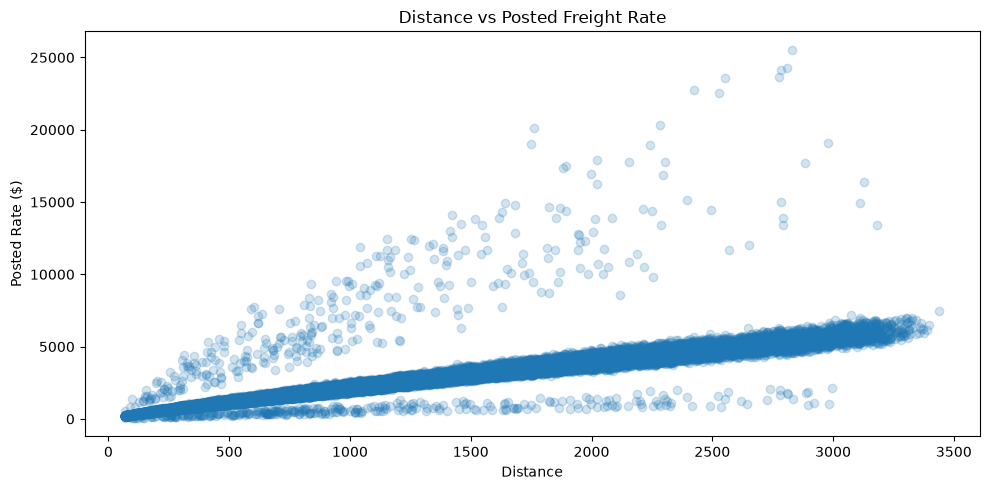

In [484]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df_clean["distance"],
    df_clean["posted_rate"],
    alpha=0.2
)

plt.xlabel("Distance")
plt.ylabel("Posted Rate ($)")
plt.title("Distance vs Posted Freight Rate")

plt.tight_layout()
plt.show()

In [485]:
df_clean["distance_band"] = pd.cut(
    df_clean["distance"],
    bins=[0, 500, 1000, 1500, 2000, 2500, 3500],
    labels=[
        "0-500",
        "500-1000",
        "1000-1500",
        "1500-2000",
        "2000-2500",
        "2500+"
    ]
)

In [486]:
df_clean.groupby("distance_band", observed=True)["rate_per_mile"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
distance_band,,,
0-500,10290,2.564907,2.495405
500-1000,15055,2.236443,2.195226
1000-1500,9008,2.125952,2.075240
1500-2000,6100,2.044124,2.000717
2000-2500,4862,1.962948,1.934275
2500+,2685,1.903365,1.869035


In [487]:
df_clean.groupby("equipment")["posted_rate"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean", ascending=False)

,count,mean,median,std
equipment,,,,
Reefer,12045,2553.636939,2196.670,1589.670824
Flatbed,8753,2445.087223,2076.810,1505.053087
Dry Van,27202,2271.548686,1953.035,1423.029914


In [488]:
df_clean.groupby("equipment")["weight"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
equipment,,,,,,
Dry Van,27202,31389.839791,31493.5,7957.704564,5000.0,47500.0
Flatbed,8753,31475.598481,31493.5,7939.630950,5000.0,47500.0
Reefer,12045,31433.054421,31493.5,7922.334202,5000.0,47500.0


In [489]:
df_clean[["weight", "posted_rate"]].corr()

,weight,posted_rate
weight,1.000000,0.041405
posted_rate,0.041405,1.000000


In [490]:
df_clean.groupby(
    df_clean["market_index"].isna()
)["posted_rate"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
market_index,,,,
False,48000,2373.980682,2030.76,1486.493245


In [491]:
df_clean[["market_index", "posted_rate"]].corr()

,market_index,posted_rate
market_index,1.000000,0.034022
posted_rate,0.034022,1.000000


In [492]:
print("Missing market_index:", df_clean["market_index"].isna().sum())
print("Total rows:", len(df_clean))

Missing market_index: 0
Total rows: 48000


In [493]:
df_clean["market_index"].describe()



count    48000.000000
mean         1.083172
std          0.167452
min          0.676390
25%          0.950610
50%          1.055800
75%          1.218525
max          1.467780
Name: market_index, dtype: float64

In [494]:
df_clean["quote_signal"].describe()

count    48000.000000
mean         2.062468
std          0.291391
min          0.692280
25%          1.891030
50%          2.055750
75%          2.221685
max          3.610350
Name: quote_signal, dtype: float64

In [495]:
df_clean[["quote_signal", "posted_rate"]].corr()

,quote_signal,posted_rate
quote_signal,1.000000,-0.039858
posted_rate,-0.039858,1.000000


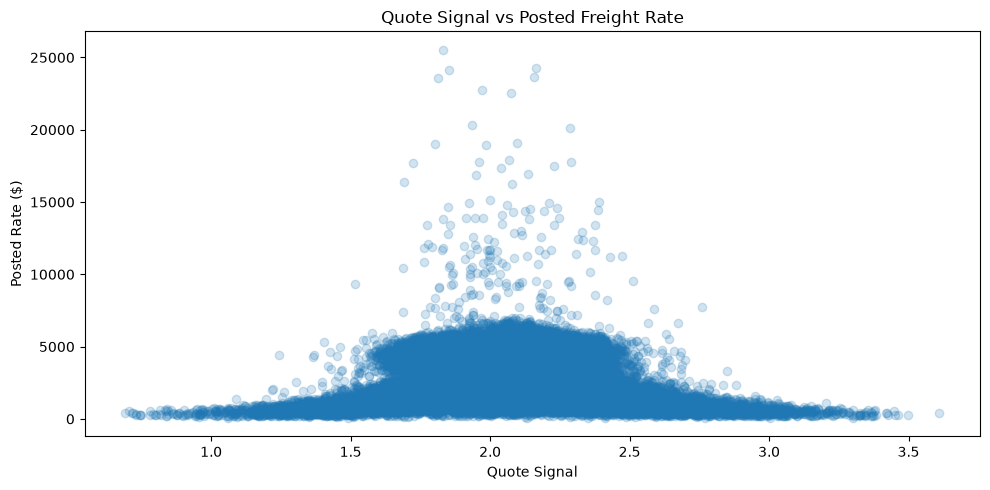

In [496]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df_clean["quote_signal"],
    df_clean["posted_rate"],
    alpha=0.2
)

plt.xlabel("Quote Signal")
plt.ylabel("Posted Rate ($)")
plt.title("Quote Signal vs Posted Freight Rate")

plt.tight_layout()
plt.show()

In [497]:
df_clean["posted_rate"].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999]
)

0.900     4365.82300
0.950     4953.76650
0.990     5972.83400
0.995     6510.96900
0.999    12854.56171
Name: posted_rate, dtype: float64

In [498]:
print(
    "Rates above $10,000:",
    (df_clean["posted_rate"] > 10000).sum()
)

print(
    "Rates above $15,000:",
    (df_clean["posted_rate"] > 15000).sum()
)

print(
    "Rates above $20,000:",
    (df_clean["posted_rate"] > 20000).sum()
)

Rates above $10,000: 103
Rates above $15,000: 24
Rates above $20,000: 9


#Feature Engineering


In [499]:
df_clean["lat_diff"] = (
    df_clean["delivery_lat"] - df_clean["pickup_lat"]
)

df_clean["lon_diff"] = (
    df_clean["delivery_lon"] - df_clean["pickup_lon"]
)

df_clean[
    [
        "pickup_lat",
        "delivery_lat",
        "lat_diff",
        "pickup_lon",
        "delivery_lon",
        "lon_diff"
    ]
].head(10)

,pickup_lat,delivery_lat,lat_diff,pickup_lon,delivery_lon,lon_diff
0,38.09122,38.16908,0.07786,-76.78906,-72.74564,4.04342
1,38.09122,39.22317,1.13195,-76.78906,-72.96710,3.82196
2,39.22317,44.30296,5.07979,-72.96710,-87.52871,-14.56161
3,39.55328,34.84933,-4.70395,-72.18051,-86.28940,-14.10889
4,31.83025,35.29479,3.46454,-94.38343,-88.08915,6.29428
5,28.75668,28.61374,-0.14294,-115.87725,-95.89569,19.98156
6,33.07921,29.50969,-3.56952,-119.79528,-98.40059,21.39469
7,35.19670,39.41104,4.21434,-121.69849,-91.12450,30.57399
8,33.28832,31.37602,-1.91230,-116.67935,-86.10743,30.57192
9,35.39918,28.75668,-6.64250,-109.59792,-115.87725,-6.27933


In [500]:
df_clean["route"] = (
    df_clean["pickup"] + " → " + df_clean["delivery"]
)

df_clean[["pickup", "delivery", "route"]].head(10)

,pickup,delivery,route
0,Richmond,Baltimore,Richmond → Baltimore
1,Richmond,Philadelphia,Richmond → Philadelphia
2,Philadelphia,Green Bay,Philadelphia → Green Bay
3,Hartford,Atlanta,Hartford → Atlanta
4,Dallas,Nashville,Dallas → Nashville
5,Phoenix,Corpus Christi,Phoenix → Corpus Christi
6,Fresno,San Antonio,Fresno → San Antonio
7,San Francisco,Kansas City,San Francisco → Kansas City
8,Bakersfield,Montgomery,Bakersfield → Montgomery
9,Albuquerque,Phoenix,Albuquerque → Phoenix


In [501]:
df_clean["date"] = pd.to_datetime(df_clean["date"])

df_clean["year"] = df_clean["date"].dt.year
df_clean["month"] = df_clean["date"].dt.month
df_clean["day"] = df_clean["date"].dt.day
df_clean["day_of_week"] = df_clean["date"].dt.dayofweek
df_clean["is_weekend"] = df_clean["day_of_week"] >= 5

df_clean[
    [
        "date",
        "year",
        "month",
        "day",
        "day_of_week",
        "is_weekend"
    ]
].head(10)

,date,year,month,day,day_of_week,is_weekend
0,2025-01-01,2025,1,1,2,False
1,2025-01-01,2025,1,1,2,False
2,2025-01-01,2025,1,1,2,False
3,2025-01-01,2025,1,1,2,False
4,2025-01-01,2025,1,1,2,False
5,2025-01-01,2025,1,1,2,False
6,2025-01-01,2025,1,1,2,False
7,2025-01-01,2025,1,1,2,False
8,2025-01-01,2025,1,1,2,False
9,2025-01-01,2025,1,1,2,False


In [502]:
categorical_features = [
    "equipment",
    "pickup",
    "delivery",
    "route"
]

for col in categorical_features:
    print(f"{col}: {df_clean[col].nunique()} unique values")

equipment: 3 unique values
pickup: 64 unique values
delivery: 64 unique values
route: 4014 unique values


In [503]:
route_counts = df_clean["route"].value_counts()

print("Total unique routes:", route_counts.nunique())
print("Routes appearing once:", (route_counts == 1).sum())
print("Routes appearing 2 times:", (route_counts == 2).sum())
print("Routes appearing 5 or fewer times:", (route_counts <= 5).sum())

Total unique routes: 39
Routes appearing once: 67
Routes appearing 2 times: 120
Routes appearing 5 or fewer times: 758


In [504]:
route_counts.describe()

count    4014.000000
mean       11.958146
std         7.165047
min         1.000000
25%         6.000000
50%        10.000000
75%        16.000000
max        39.000000
Name: count, dtype: float64

In [505]:
route_frequency_distribution = route_counts.value_counts().sort_index()

route_frequency_distribution.head(20)

count
1      67
2     120
3     150
4     200
5     221
6     249
7     272
8     242
9     239
10    250
11    209
12    174
13    173
14    170
15    158
16    152
17    119
18    120
19    107
20     82
Name: count, dtype: int64

In [506]:
route_frequency_distribution.tail(10)

count
30    14
31    11
32    12
33    10
34     6
35    12
36     2
37     6
38     1
39     3
Name: count, dtype: int64

In [507]:
df_clean.groupby(["pickup", "delivery"])["posted_rate"].agg(
    ["count", "mean", "median"]
).sort_values("count", ascending=False).head(20)

count         mean    median
pickup        delivery                                   
Columbia      Oklahoma City     39  2330.734615  2327.430
Phoenix       Shreveport        39  3507.618462  3554.430
Lexington     Atlanta           39   560.106154   553.630
Fort Wayne    Philadelphia      38  1681.032632  1708.835
Shreveport    Hartford          37  2867.768108  2812.520
Fort Wayne    Hartford          37  1938.657297  1725.990
Richmond      Oklahoma City     37  3093.435946  3126.490
              Phoenix           37  5190.194595  5010.880
Lexington     Kansas City       37  1042.474595  1029.800
              Cincinnati        37   396.691892   377.100
Fort Wayne    Cincinnati        36   871.521111   857.150
Mobile        Phoenix           36  4180.469167  3842.000
Richmond      Cincinnati        35  1472.597143  1445.430
Oklahoma City Nashville         35  1737.457143  1744.960
Hartford      Baton Rouge       35  3102.180571  3101.260
Oklahoma City Atlanta           35  1895.603714  1909.990
              Columbia          35  2333.602857  2279.320
Bakersfield   Hartford          35  5998.482286  5402.590
Oklahoma City Mobile            35  1517.043143  1644.700
Philadelphia  Lexington         35  1708.174857  1691.690

In [508]:
df_clean.groupby("pickup")["posted_rate"].agg(
    ["count", "mean", "median"]
).sort_values("count", ascending=False).head(15)

,count,mean,median
pickup,,,
Oklahoma City,1242,2219.075097,2138.895
Lexington,1209,1824.140273,1374.590
Bakersfield,1193,3519.365448,3804.880
Fort Wayne,1170,1996.960462,1711.435
Hartford,1150,2671.385409,2228.705
Richmond,1140,2288.463088,1746.695
Nashville,1124,1761.969226,1435.715
Phoenix,1121,3764.774764,3935.620
Baton Rouge,1115,2105.062404,1902.940


In [509]:
df_clean.groupby("delivery")["posted_rate"].agg(
    ["count", "mean", "median"]
).sort_values("count", ascending=False).head(15)

,count,mean,median
delivery,,,
Lexington,1197,1825.932698,1391.980
Fort Wayne,1176,1981.883495,1700.170
Baton Rouge,1167,2109.520060,1939.010
Bakersfield,1156,3532.198893,3742.535
Hartford,1143,2686.995372,2248.050
Oklahoma City,1140,2332.683702,2224.920
Richmond,1109,2231.707448,1691.980
Atlanta,1096,1796.178449,1475.730
Phoenix,1090,3751.473110,3921.980


In [510]:
categorical_features = [
    "equipment",
    "pickup",
    "delivery"
]

numerical_features = [
    "distance",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "weight", .
    
    "market_index",
    "quote_signal"
]

target = "posted_rate"

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)
print("Target:", target)

SyntaxError: invalid syntax (1310046192.py, line 13)

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean[categorical_features + numerical_features]
y = df_clean[target]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 38400
Validation samples: 9600


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['distance', 'pickup_lat', 'pickup_lon',
                                  'delivery_lat', 'delivery_lon', 'weight',
                                  'market_index', 'quote_signal']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['equipment', 'pickup', 'delivery'])])


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print("Training shape:", X_train_processed.shape)
print("Validation shape:", X_val_processed.shape)

Training shape: (38400, 139)
Validation shape: (9600, 139)


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
baseline_model = LinearRegression()

In [ ]:
baseline_model.fit(X_train_processed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](139,)","[1366.92, -40.04, 16.59,..., -41.35, 36.09, -48.3 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2422
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,139


In [511]:
y_train_pred = baseline_model.predict(X_train_processed)
y_val_pred = baseline_model.predict(X_val_processed)

In [512]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [513]:
train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("Baseline Linear Regression")
print("--------------------------")
print(f"Train MAE:  ${train_mae:,.2f}")
print(f"Val MAE:    ${val_mae:,.2f}")
print()
print(f"Train RMSE: ${train_rmse:,.2f}")
print(f"Val RMSE:   ${val_rmse:,.2f}")
print()
print(f"Train R²:   {train_r2:.4f}")
print(f"Val R²:     {val_r2:.4f}")

Baseline Linear Regression
--------------------------
Train MAE:  $146.87
Val MAE:    $140.65

Train RMSE: $614.42
Val RMSE:   $537.22

Train R²:   0.8305
Val R²:     0.8651


In [514]:
comparison = pd.DataFrame({
    "actual": y_val.values,
    "predicted": y_val_pred
})

comparison["error"] = comparison["actual"] - comparison["predicted"]
comparison["absolute_error"] = comparison["error"].abs()

comparison.head(10)

,actual,predicted,error,absolute_error
0,1179.97,1271.719083,-91.749083,91.749083
1,2461.67,2401.568337,60.101663,60.101663
2,3653.22,3450.081222,203.138778,203.138778
3,3937.32,1176.130043,2761.189957,2761.189957
4,4264.12,4621.179681,-357.059681,357.059681
5,4682.00,5401.135120,-719.135120,719.135120
6,2911.04,3034.197011,-123.157011,123.157011
7,2825.22,2815.170767,10.049233,10.049233
8,393.24,687.550357,-294.310357,294.310357
9,4047.30,4053.861861,-6.561861,6.561861


In [515]:
comparison.sort_values(
    "absolute_error",
    ascending=False
).head(20)

,actual,predicted,error,absolute_error
5101,17893.17,4066.068408,13827.101592,13827.101592
1051,17688.63,5415.579125,12273.050875,12273.050875
6823,14079.19,2988.920035,11090.269965,11090.269965
5024,14317.13,3387.351106,10929.778894,10929.778894
3855,14561.21,3822.244328,10738.965672,10738.965672
3162,13435.73,3284.440494,10151.289506,10151.289506
757,14425.42,4739.971929,9685.448071,9685.448071
7336,11981.00,2774.906595,9206.093405,9206.093405
1865,11797.79,3090.769101,8707.020899,8707.020899
3436,11276.81,2631.656974,8645.153026,8645.153026


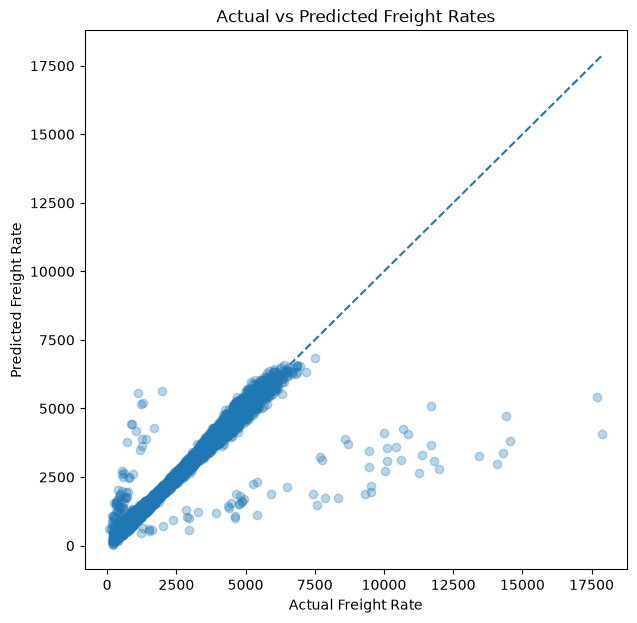

In [516]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(y_val, y_val_pred, alpha=0.3)

plt.xlabel("Actual Freight Rate")
plt.ylabel("Predicted Freight Rate")
plt.title("Actual vs Predicted Freight Rates")

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--"
)

plt.show()

In [517]:
residuals = y_val - y_val_pred

print("Residual summary:")
print(residuals.describe())

Residual summary:
count     9600.000000
mean        -3.056819
std        537.235032
min      -4452.686162
25%        -96.868959
50%        -20.106528
75%         47.633778
max      13827.101592
Name: posted_rate, dtype: float64


In [518]:
error_analysis = df_clean.loc[y_val.index, [
    "posted_rate",
    "equipment",
    "pickup",
    "delivery",
    "distance",
    "weight",
    "market_index",
    "quote_signal"
]].copy()

error_analysis["predicted_rate"] = y_val_pred
error_analysis["error"] = y_val - y_val_pred
error_analysis["absolute_error"] = abs(error_analysis["error"])

error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(20)

,posted_rate,equipment,pickup,delivery,distance,weight,market_index,quote_signal,predicted_rate,error,absolute_error
46213,17893.17,Flatbed,Columbia,Tucson,2023.4,34710.0,0.89822,2.06797,4066.068408,13827.101592,13827.101592
4657,17688.63,Dry Van,Baltimore,Reno,2884.1,35317.0,1.06754,1.72427,5415.579125,12273.050875,12273.050875
21609,14079.19,Flatbed,Albuquerque,Milwaukee,1421.3,27841.0,1.23694,2.04142,2988.920035,11090.269965,11090.269965
28824,14317.13,Dry Van,Washington,Lubbock,1627.6,38611.0,1.25439,2.08207,3387.351106,10929.778894,10929.778894
20882,14561.21,Flatbed,Reno,Memphis,1869.7,31493.5,1.26327,2.24126,3822.244328,10738.965672,10738.965672
32677,13435.73,Dry Van,Dallas,Baltimore,1547.6,34852.0,1.06736,2.23071,3284.440494,10151.289506,10151.289506
44267,14425.42,Dry Van,Albany,Albuquerque,2492.6,25513.0,1.05590,2.38846,4739.971929,9685.448071,9685.448071
37173,11981.00,Flatbed,Albuquerque,Madison,1327.4,36335.0,0.97029,1.90503,2774.906595,9206.093405,9206.093405
35833,11797.79,Reefer,Green Bay,Amarillo,1384.6,37596.0,1.04156,1.83041,3090.769101,8707.020899,8707.020899
28597,11276.81,Reefer,Richmond,Shreveport,1106.1,32640.0,1.20681,2.47240,2631.656974,8645.153026,8645.153026


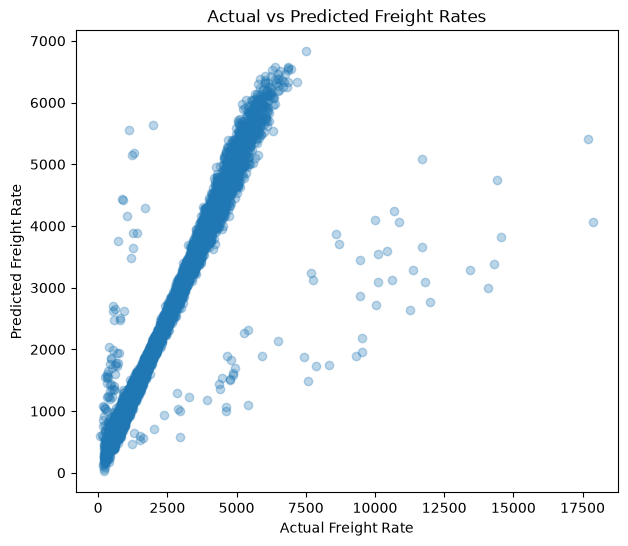

In [519]:

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(y_val, y_val_pred, alpha=0.3)

plt.xlabel("Actual Freight Rate")
plt.ylabel("Predicted Freight Rate")
plt.title("Actual vs Predicted Freight Rates")

plt.show()



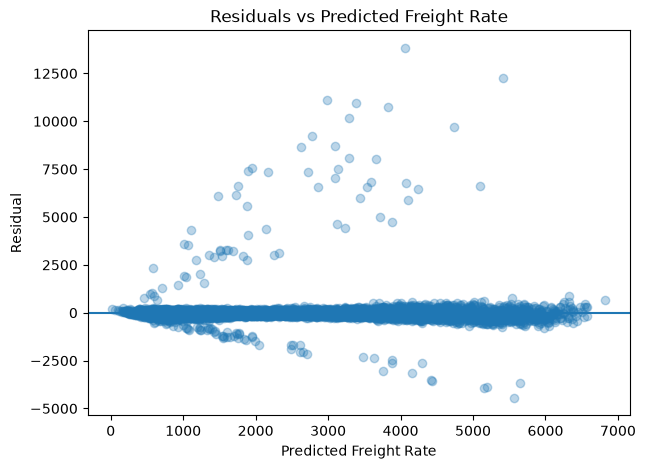

In [520]:
plt.figure(figsize=(7, 5))

plt.scatter(y_val_pred, residuals, alpha=0.3)

plt.axhline(y=0)

plt.xlabel("Predicted Freight Rate")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Freight Rate")

plt.show()